# Access the analysis ready fire danger indices historical data

This notebook provides an example of how to open the cems-fire-historical-v1 Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds.climate.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Geo-chunked Canadian FWI system consolidated data
geochunked_canada_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/canada-consolidated/geoChunked.zarr"

# Time-chunked Canadian FWI system consolidated data
timechunked_canada_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/canada-consolidated/timeChunked.zarr"

# Geo-chunked Canadian FWI system intermediate data
geochunked_canada_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/canada-intermediate/geoChunked.zarr"

# Time-chunked Canadian FWI system intermediate data
timechunked_canada_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/canada-intermediate/timeChunked.zarr"

# Geo-chunked Australian McArthur Mark 5 consolidated data
geochunked_australia_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/australia-consolidated/geoChunked.zarr"

# Time-chunked Australian McArthur Mark 5 consolidated data
timechunked_australia_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/australia-consolidated/timeChunked.zarr"

# Geo-chunked Australian McArthur Mark 5 intermediate data
geochunked_australia_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/australia-intermediate/geoChunked.zarr"

# Time-chunked Australian McArthur Mark 5 intermediate data
timechunked_australia_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/australia-intermediate/timeChunked.zarr"

# Geo-chunked US NFDRRS consolidated data
geochunked_us_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/us-consolidated/geoChunked.zarr"

# Time-chunked US NFDRRS consolidated data
timechunked_us_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/us-consolidated/timeChunked.zarr"

# Geo-chunked US NFDRRS intermediate data
geochunked_us_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/us-intermediate/geoChunked.zarr"

# Time-chunked US NFDRRS intermediate data
timechunked_us_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/us-intermediate/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    timechunked_canada_consolidated_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 915GB
Dimensions:    (time: 31469, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 252kB 1940-01-03 1940-01-04 ... 2026-02-28
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    drtcode    (time, latitude, longitude) float32 131GB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    dufmcode   (time, latitude, longitude) float32 131GB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    fbupinx    (time, latitude, longitude) float32 131GB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    fdsrte     (time, latitude, longitude) float32 131GB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    ffmcode    (time, latitude, longitude) float32 131GB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    fwinx      (time, latitude, longitude) float32 131GB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
    infsinx    (time, latitude, longitude) float32 131GB dask.array<chunksize=(1, 721, 1024), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            2
    GRIB_subCentre:          0
    history:                 2026-03-16T03:16 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

Plot a map of the Canadian Fire Weather Index (FWI) using earthkit-plots.

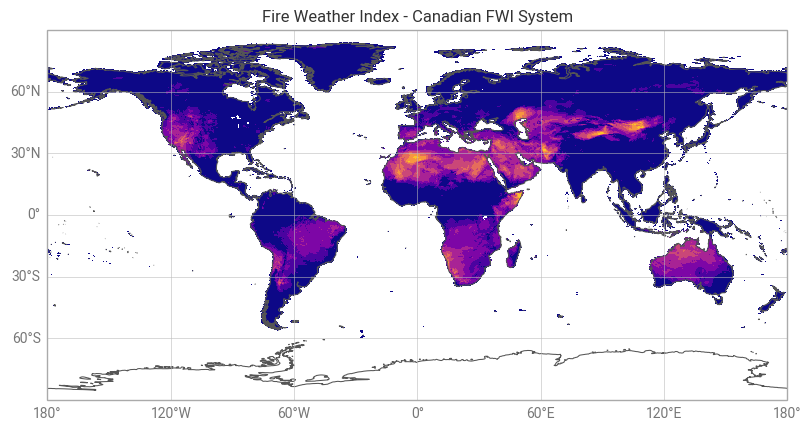

In [3]:
from earthkit import plots as ekp

# Select a single time step to plot
plot_data = ds["fwinx"].sel(time="2020-08-01", method="nearest")

chart = ekp.Map()

chart.grid_cells(plot_data)

chart.coastlines()
chart.gridlines()

chart.title("Fire Weather Index - Canadian FWI System")

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked Canadian FWI system consolidated data
geochunked_canada_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/canada-consolidated/geoChunked.zarr"

# Time-chunked Canadian FWI system consolidated data
timechunked_canada_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/canada-consolidated/timeChunked.zarr"

# Geo-chunked Canadian FWI system intermediate data
geochunked_canada_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/canada-intermediate/geoChunked.zarr"

# Time-chunked Canadian FWI system intermediate data
timechunked_canada_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/canada-intermediate/timeChunked.zarr"

# Geo-chunked Australian McArthur Mark 5 consolidated data
geochunked_australia_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/australia-consolidated/geoChunked.zarr"

# Time-chunked Australian McArthur Mark 5 consolidated data
timechunked_australia_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/australia-consolidated/timeChunked.zarr"

# Geo-chunked Australian McArthur Mark 5 intermediate data
geochunked_australia_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/australia-intermediate/geoChunked.zarr"

# Time-chunked Australian McArthur Mark 5 intermediate data
timechunked_australia_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/australia-intermediate/timeChunked.zarr"

# Geo-chunked US NFDRRS consolidated data
geochunked_us_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/us-consolidated/geoChunked.zarr"

# Time-chunked US NFDRRS consolidated data
timechunked_us_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/us-consolidated/timeChunked.zarr"

# Geo-chunked US NFDRRS intermediate data
geochunked_us_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cems_fire_historical_v1/us-intermediate/geoChunked.zarr"

# Time-chunked US NFDRRS intermediate data
timechunked_us_intermediate_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cems_fire_historical_v1/us-intermediate/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_canada_consolidated_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


<xarray.Dataset> Size: 915GB
Dimensions:    (time: 31469, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 252kB 1940-01-03 1940-01-04 ... 2026-02-28
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    drtcode    (time, latitude, longitude) float32 131GB dask.array<chunksize=(8448, 8, 16), meta=np.ndarray>
    dufmcode   (time, latitude, longitude) float32 131GB dask.array<chunksize=(8448, 8, 16), meta=np.ndarray>
    fbupinx    (time, latitude, longitude) float32 131GB dask.array<chunksize=(8448, 8, 16), meta=np.ndarray>
    fdsrte     (time, latitude, longitude) float32 131GB dask.array<chunksize=(8448, 8, 16), meta=np.ndarray>
    ffmcode    (time, latitude, longitude) float32 131GB dask.array<chunksize=(8448, 8, 16), meta=np.ndarray>
    fwinx      (time, latitude, longitude) float32 131GB dask.array<chunksize=(8448, 8, 16), meta=np.ndarray>
    infsinx    (time, latitude, longitude) float32 131GB dask.array<chunksize=(8448, 8, 16), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            2
    GRIB_subCentre:          0
    history:                 2026-03-16T03:16 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.